In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import nltk
from textblob import TextBlob 

nltk.download('punkt')
nltk.download('stopwords')

print("All libraries loaded successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mzbur\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


All libraries loaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mzbur\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [2]:
# Load the financial news dataset 
df = pd.read_csv('../data/all-data.csv', 
                encoding='latin-1',
                 header=None,
                  names=['sentiment', 'text'])

print("Data loaded!")
print("Rows and columns:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Data loaded!
Rows and columns: (4846, 2)

First 5 rows:
  sentiment                                               text
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...

Sentiment distribution:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [3]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = text.strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("Text cleaned!")
print("\nOriginal:")
print(df['text'][0])
print("\nCleaned:")
print(df['clean_text'][0])

Text cleaned!

Original:
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

Cleaned:
according to gran  the company has no plans to move all production to russia  although that is where the company is growing


In [4]:
# Create SQL database
conn = sqlite3.connect('../sql/financial_news.db')

# Save to SQL
df.to_sql('news_sentiment', conn, if_exists='replace', index=False)

print("Database created!")
print("Table 'news_sentiment' loaded with", len(df), "rows")

Database created!
Table 'news_sentiment' loaded with 4846 rows


In [5]:
# Query 1 - Sentiment distribution
query1 = """
SELECT
    sentiment,
    COUNT(*) as total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
FROM news_sentiment
GROUP BY sentiment
ORDER BY total DESC
""" 

results1 = pd.read_sql_query(query1, conn)
print("Sentiment Distribution:")
print(results1)


Sentiment Distribution:
  sentiment  total  percentage
0   neutral   2879       59.41
1  positive   1363       28.13
2  negative    604       12.46


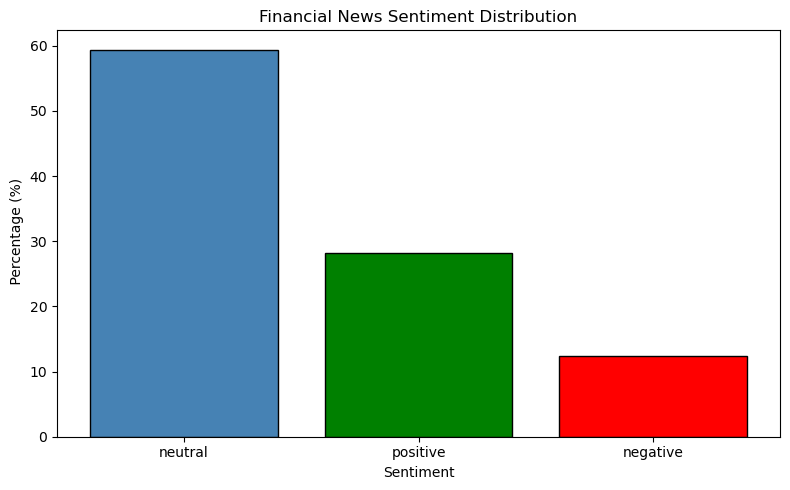

Chart saved!


In [6]:
plt.figure(figsize=(8, 5))
colors = ['steelblue', 'green', 'red']
plt.bar(results1['sentiment'], results1['percentage'],
        color=colors, edgecolor='black')
plt.title('Financial News Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel(' Percentage (%)')
plt.tight_layout()
plt.savefig('../outputs/sentiment_distribution.png')
plt.show()

print("Chart saved!")

In [9]:
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0.1:
        return 'positive'
    elif analysis.sentiment.polarity < -0.1:
        return 'negative'
    else:
        return 'neutral' 
    
df['predicted_sentiment'] = df['clean_text'].apply(get_sentiment)

print("Sentiment analysis complete!")
print("\nPredicted Distribution:")

Sentiment analysis complete!

Predicted Distribution:


In [10]:
print(df['predicted_sentiment'].value_counts())
print(df['predicted_sentiment'].dtype)

predicted_sentiment
neutral     3291
positive    1128
negative     427
Name: count, dtype: int64
object


In [11]:
# Clean up sentiment labels
df['predicted_sentiment'] = df['predicted_sentiment'].str.strip().str.lower()
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Compare predictions to actual labels
correct = (df['predicted_sentiment'] == df['sentiment']).sum()
accuracy = correct / len(df) * 100

print(f"TextBlob Accuracy: {accuracy:.2f}%")
print("\nComparison")
print(pd.crosstab(df['sentiment'], df['predicted_sentiment'],
                  rownames=['Actual'], colnames=['Predicted']))

TextBlob Accuracy: 54.73%

Comparison
Predicted  negative  neutral  positive
Actual                                
negative        145      397        62
neutral         224     2048       607
positive         58      846       459


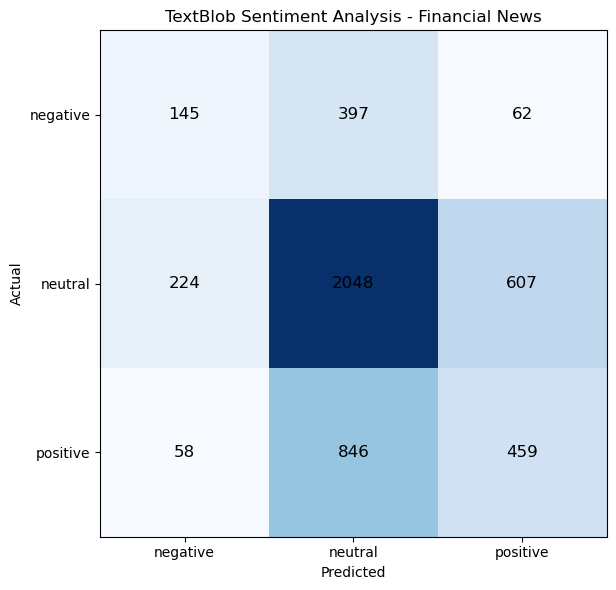

Chart saved!


In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np 

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(df['sentiment'], df['predicted_sentiment'], labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('TextBlob Sentiment Analysis - Financial News')

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='black', fontsize=12)
        
plt.tight_layout()
plt.savefig('../outputs/sentiment_confusion_matrix.png')
plt.show()

print("Chart saved!")

In [16]:
from collections import Counter

# Most common words in positive news
positive_text = ' '.join(df[df['sentiment'] == 'positive']['clean_text'])
positive_words = Counter(positive_text.split()).most_common(10)

# Most common words in negative news
negative_text = ' '.join(df[df['sentiment'] == 'negative']['clean_text'])
negative_words = Counter(negative_text.split()).most_common(10)

print("Top 10 words in POSITIVE financial news:")
for word, count in positive_words:
    print(f"  {word}: {count}")

print("\nTop 10 words in NEGATIVE financial news:")
for word, count in negative_words:
    print(f"  {word}: {count}")

Top 10 words in POSITIVE financial news:
  the: 1587
  in: 969
  to: 918
  of: 852
  and: 679
  eur: 595
  a: 528
  for: 387
  from: 358
  s: 329

Top 10 words in NEGATIVE financial news:
  the: 759
  in: 473
  of: 440
  eur: 400
  to: 363
  mn: 237
  a: 229
  from: 208
  and: 197
  profit: 156


In [23]:
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(filtered)

df['filtered_text'] = df['clean_text'].apply(remove_stopwords)

# Rerun word frequency
positive_text = ' '.join(df[df['sentiment'] == 'positive']['filtered_text'])
positive_words = Counter(positive_text.split()).most_common(10)

negative_text = ' '.join(df[df['sentiment'] == 'negative']['filtered_text'])
negative_words = Counter(negative_text.split()).most_common(10)

print("Top 10 words in POSITIVE financial news:")
for word, count in positive_words:
    print(f"  {word}: {count}")

print("\nTop 10 words in NEGATIVE financial news:")
for word, count in negative_words:
    print(f"  {word}: {count}")

Top 10 words in POSITIVE financial news:
  eur: 595
  company: 240
  said: 230
  finnish: 198
  net: 196
  sales: 192
  profit: 191
  million: 170
  year: 143
  period: 139

Top 10 words in NEGATIVE financial news:
  eur: 400
  profit: 156
  net: 104
  company: 100
  finnish: 99
  sales: 98
  operating: 97
  period: 88
  quarter: 79
  million: 78


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mzbur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
